RUNNING BASE CASE SCENARIO:
--- Monte Carlo Simulation Results ---
Iterations run: 10000
Input Sales Volume Mean: 100.0%
Input Sales Volume Std Dev: 10.0%

Mean (Expected) NPV: £457.86k
Probability of Negative NPV: 13.17%
5th Percentile (Worst-Case): £-219.36k
95th Percentile (Best-Case): £1131.86k


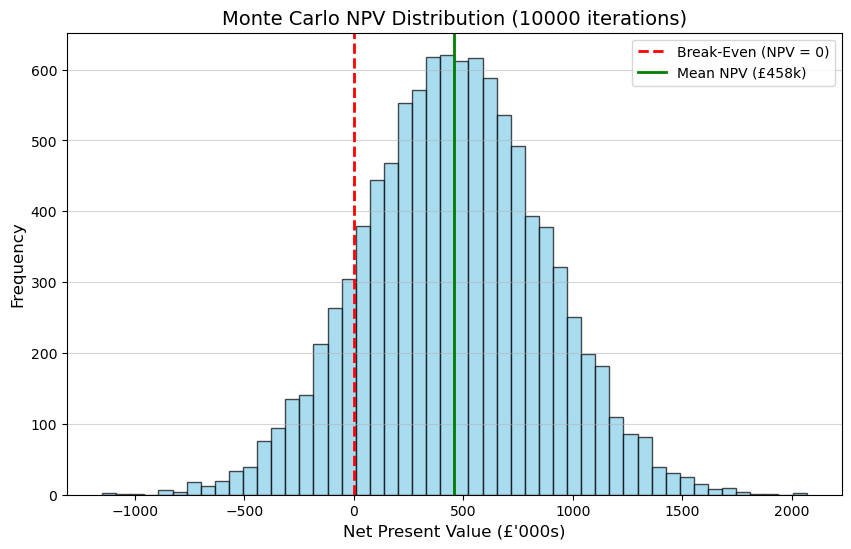

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def run_cnc_monte_carlo(mean_volume=1.0, std_dev_volume=0.1, n_iterations=10000):
    """
    Runs a Monte Carlo simulation for the CNC Milling Machine project.
    
    Parameters:
    mean_volume (float): The expected sales volume multiplier (default 1.0 = 100%).
    std_dev_volume (float): The standard deviation of the sales volume (default 0.1 = 10%).
    n_iterations (int): The number of simulation runs (default 10,000).
    """
    # Set random seed for reproducibility
    np.random.seed(42)

    # Base case variable parameters (in £'000s) - Years 1 to 4
    base_sales = np.array([4000.0, 6000.0, 8000.0, 6000.0])
    base_materials = np.array([-2200.0, -3000.0, -3800.0, -3000.0])
    base_labour = np.array([-800.0, -1200.0, -1200.0, -800.0])

    # Fixed & predefined parameters (in £'000s)
    cannibalisation = -150.0
    other_production = np.array([-640.0, -660.0, -680.0, -840.0]) # Adjusted for 20% allocated overheads
    marketing = np.array([-80.0, -80.0, -80.0, -80.0])
    savings_old_machine = 180.0
    old_machine_scrap_lost = np.array([0.0, 0.0, 0.0, -8.0])
    
    # Tax and Depreciation parameters
    capital_allowances = np.array([-600.0, -450.0, -337.5, -812.5]) 
    tax_rate = 0.30
    wacc = 0.1005 # 10.05% Discount Rate

    # 1. Simulate Volume Multiplier based on input parameters
    volume_multiplier = np.random.normal(mean_volume, std_dev_volume, n_iterations)

    # Array to store the NPV of each run
    npv_results = np.zeros(n_iterations)

    # 2. Run the simulation
    for i in range(n_iterations):
        vol = volume_multiplier[i]
        
        # Scale variable revenues and costs by the randomized volume
        sales = base_sales * vol
        materials = base_materials * vol
        labour = base_labour * vol
        
        # Scale Working Capital requirements
        # Base WC inventory levels required at the end of each year: Y0=400, Y1=800, Y2=800, Y3=600, Y4=0
        wc_req = np.array([400.0, 800.0, 800.0, 600.0, 0.0]) * vol
        
        # Calculate the incremental cash flows from Working Capital changes
        delta_wc = np.zeros(5)
        delta_wc[0] = -wc_req[0] # Y0 outflow to build initial stock
        for j in range(1, 5):
            delta_wc[j] = -(wc_req[j] - wc_req[j-1]) # Subsequent year-on-year changes

        # Pre-Tax Operating Cash Flow (EBITDA) Y1-Y4
        ebitda = sales + materials + labour + other_production + marketing + savings_old_machine + cannibalisation + old_machine_scrap_lost
        
        # Taxable income (Capital allowances are entered as negative numbers, so we add them to reduce taxable income)
        taxable_income = ebitda + capital_allowances
        
        # Tax paid / saved (Negative because it's a cash outflow if taxable income > 0)
        tax = -taxable_income * tax_rate
        
        # Net Free Cash Flow (Years 1 to 4)
        fcf = ebitda + tax + delta_wc[1:]
        
        # Add terminal scrap value of new machine in Y4 (+£200k)
        fcf[1] += 200.0
        
        # Year 0 Free Cash Flow
        # Initial Investment (-2400), Old Machine Sale (+200), Tax on old (-60), Upfront Marketing (-400), Initial WC
        fcf_0 = -2400.0 + 200.0 - 60.0 - 400.0 + delta_wc[0]

        # 3. Discount the cash flows to Year 0 using 10.05% WACC
        discount_factors = np.array([1 / ((1 + wacc) ** (t + 1)) for t in range(4)])
        npv = fcf_0 + np.sum(fcf * discount_factors)
        
        npv_results[i] = npv

    # 4. Analyze the Distribution of NPVs
    mean_npv = np.mean(npv_results)
    prob_neg = np.mean(npv_results < 0) * 100
    p5 = np.percentile(npv_results, 5)
    p95 = np.percentile(npv_results, 95)

    # 5. Output text formatting
    print(f"--- Monte Carlo Simulation Results ---")
    print(f"Iterations run: {n_iterations}")
    print(f"Input Sales Volume Mean: {mean_volume*100:.1f}%")
    print(f"Input Sales Volume Std Dev: {std_dev_volume*100:.1f}%\n")
    print(f"Mean (Expected) NPV: £{mean_npv:.2f}k")
    print(f"Probability of Negative NPV: {prob_neg:.2f}%")
    print(f"5th Percentile (Worst-Case): £{p5:.2f}k")
    print(f"95th Percentile (Best-Case): £{p95:.2f}k")
    
    # 6. Plotting the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(npv_results, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Break-Even (NPV = 0)')
    plt.axvline(mean_npv, color='green', linestyle='solid', linewidth=2, label=f'Mean NPV (£{mean_npv:.0f}k)')
    plt.title(f"Monte Carlo NPV Distribution ({n_iterations} iterations)", fontsize=14)
    plt.xlabel("Net Present Value (£'000s)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

    return npv_results

# ---------------------------------------------------------
# EXECUTE THE FUNCTION HERE
# You can change the Mean and Standard Deviation parameters 
# ---------------------------------------------------------

# Default Run (100% Target, 10% Volatility)
print("RUNNING BASE CASE SCENARIO:")
results_base = run_cnc_monte_carlo(mean_volume=1.0, std_dev_volume=0.10, n_iterations=10000)

# Example of a highly volatile scenario (100% Target, 25% Volatility)
# print("\nRUNNING HIGH VOLATILITY SCENARIO:")
# results_volatile = run_cnc_monte_carlo(mean_volume=1.0, std_dev_volume=0.25)

# Example of a pessimistic scenario (85% Target, 10% Volatility)
# print("\nRUNNING PESSIMISTIC SCENARIO:")
# results_pessimistic = run_cnc_monte_carlo(mean_volume=0.85, std_dev_volume=0.10)